>>Designing a predictive model that predicts real estate prices basing on features such as price, size and year
This is a regression problem because we are predicting continuous price

Group 8 
1. Nakabugo Catherine —DSMA/DAY/1522
2. Ssekasanvu Shafick DSMA/DAY/G/1500
3. Maroma John-2025/DSMA/DAY/1986
4. Yawe Rodgers/DSMa/DAY/1535
5. Nakayenga Melisa DSMA/DAY/1558
6. NELSON SSEMPA 2025/DSMA/DAY/0476

In [1]:
#importing required libraries for data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading the dataset
df= pd.read_csv("real_estate.csv")
df

,price,size,year,view
0,234314.144,643.09,2015,No sea view
1,228581.528,656.22,2009,No sea view
2,281626.336,487.29,2018,Sea view
3,401255.608,1504.75,2015,No sea view
4,458674.256,1275.46,2009,Sea view
...,...,...,...,...
95,252460.400,549.80,2009,Sea view
96,310522.592,1037.44,2009,No sea view
97,383635.568,1504.75,2006,No sea view
98,225145.248,648.29,2015,No sea view


In [3]:
df.isnull().sum()

price    0
size     0
year     0
view     0
dtype: int64

In [4]:
df.dtypes

price    float64
size     float64
year       int64
view      object
dtype: object

In [5]:
df["view"] = df["view"].map({'Sea view': 1, 'No sea view': 0})
#Machine learning models like linear regression can’t directly handle text labels. They need numeric input.

In [6]:
#creating a new variable and dropping 'year'
current_year = 2026
df['property_age'] = current_year - df['year']
df = df.drop('year', axis=1)

In [7]:
df["view"]= df["view"].astype("category").cat.codes

In [8]:
df.dtypes

price           float64
size            float64
view               int8
property_age      int64
dtype: object

EXPLORATORY DATA ANALYSIS


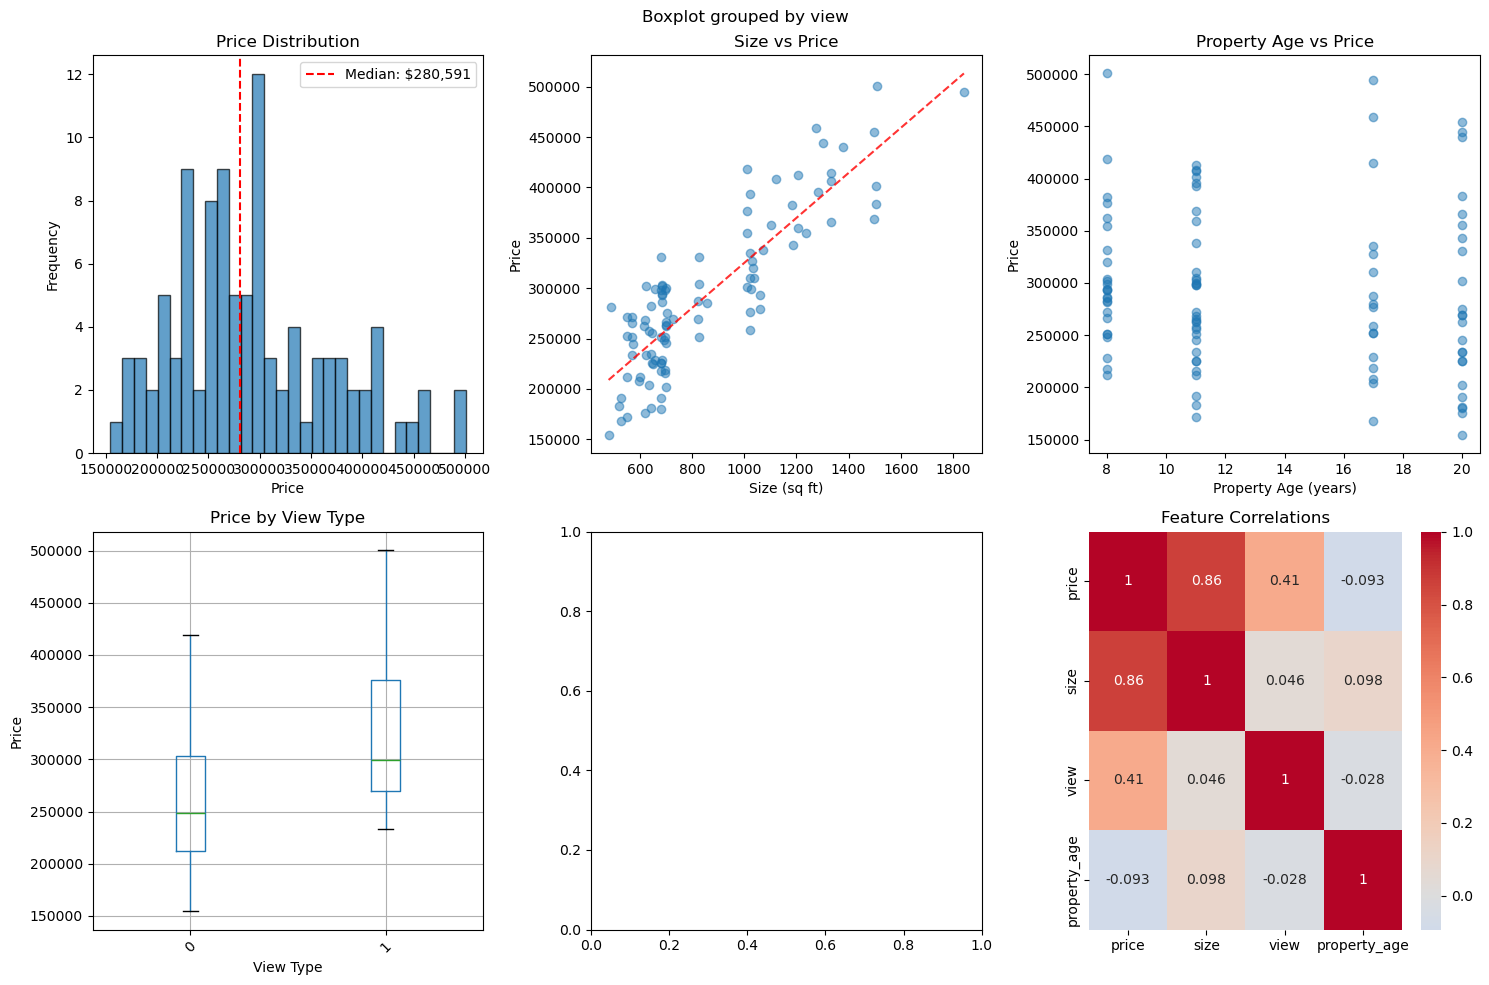

In [9]:
# EXPLORATORY DATA ANALYSIS
print("EXPLORATORY DATA ANALYSIS")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

#Price distribution
axes[0, 0].hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: ${df['price'].median():,.0f}")
axes[0, 0].legend()

#Size vs Price scatter
axes[0, 1].scatter(df['size'], df['price'], alpha=0.5)
axes[0, 1].set_xlabel('Size (sq ft)')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('Size vs Price')
# Add trend line
z = np.polyfit(df['size'], df['price'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df['size'].sort_values(), p(df['size'].sort_values()), "r--", alpha=0.8)

#Property Age vs Price
axes[0, 2].scatter(df['property_age'], df['price'], alpha=0.5)
axes[0, 2].set_xlabel('Property Age (years)')
axes[0, 2].set_ylabel('Price')
axes[0, 2].set_title('Property Age vs Price')

#Box plot: View type vs Price
view_categories = df.groupby('view')['price'].agg(['mean', 'median'])
df.boxplot(column='price', by='view', ax=axes[1, 0])
axes[1, 0].set_title('Price by View Type')
axes[1, 0].set_xlabel('View Type')
axes[1, 0].set_ylabel('Price')
axes[1, 0].tick_params(axis='x', rotation=45)


#Correlation heatmap (numeric only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()

In [10]:
#importing necessary libraries for moedling
from sklearn.model_selection import train_test_split #Used to split data into training and testing sets.
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, StandardScaler #Converts labels into numbers. Converts categories into binary columns. Standardizes numerical values.  
from sklearn.compose import ColumnTransformer #Applies different preprocessing to different columns.
from sklearn.linear_model import LinearRegression #Fits a straight-line relationship between features and target.
from sklearn.svm import SVR #Support Vector Machine for regression tasks.
from sklearn.model_selection import cross_val_score #Evaluates a model across multiple train-test splits.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [11]:
X = df.drop(['price'], axis=1) #the inputs used to make predictions.
y = df['price'] #the value you want the model to predict.

In [12]:
# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['int8', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features: {numeric_cols}")
print(f"Categorical features: {categorical_cols}")

Numeric features: ['size', 'view', 'property_age']
Categorical features: ['view']


In [13]:
# Create preprocessor(prepares raw data before it is sent to a machine learning model.)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=123)

In [15]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Coefficients:", model.coef_) 
#These tell you how much the target variable changes when a feature increases by 1 unit, while keeping all other features constant.
print("Intercept:", model.intercept_)
#This is the predicted value when all features are zero.
print("R² Score:", r2_score(y_test, y_pred))
#R² measures how much of the variation in the target is explained by the model.
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
#RMSE measures the average prediction error in the same units as the target variable.

Coefficients: [  219.85544122 55245.70199732 -2691.85890511]
Intercept: 113456.90019688624
R² Score: 0.9137597474307073
RMSE: 21637.616624892373


In [17]:
print(model.feature_names_in_)

['size' 'view' 'property_age']


In [18]:
print("SAMPLE PREDICTIONS")
# Create sample properties to predict
sample_properties = pd.DataFrame([
    {'size': 1000,'view': 1, 'property_age': 0},
    {'size': 800, 'view': 0, 'property_age': 5},
    {'size': 1200,'view': 1, 'property_age': 10},
    {'size': 600, 'view': 0, 'property_age': 20},
    {'size': 1500,'view': 1, 'property_age': 2}
])
# Make predictions
sample_predictions = model.predict(sample_properties)

print("\nPredicted prices for sample properties:")
sample_properties['predicted_price'] = sample_predictions
for i, row in sample_properties.iterrows():
    print(f"\nProperty {i+1}:")
    print(f"  Size: {row['size']} sq ft")
    print(f"  Age: {row['property_age']} years")
    print(f"  View: {row['view']}")
    print(f"  Predicted Price: ${row['predicted_price']:,.2f}")

print("MODELING COMPLETE")

SAMPLE PREDICTIONS

Predicted prices for sample properties:

Property 1:
  Size: 1000.0 sq ft
  Age: 0.0 years
  View: 1.0
  Predicted Price: $388,558.04

Property 2:
  Size: 800.0 sq ft
  Age: 5.0 years
  View: 0.0
  Predicted Price: $275,881.96

Property 3:
  Size: 1200.0 sq ft
  Age: 10.0 years
  View: 1.0
  Predicted Price: $405,610.54

Property 4:
  Size: 600.0 sq ft
  Age: 20.0 years
  View: 0.0
  Predicted Price: $191,532.99

Property 5:
  Size: 1500.0 sq ft
  Age: 2.0 years
  View: 1.0
  Predicted Price: $493,102.05
MODELING COMPLETE


In [20]:
import joblib
joblib.dump(model, "price_model.pkl")

['price_model.pkl']

In [21]:
!pip install streamlit

In [22]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("price_model.pkl")
st.title("PRICE Prediction App")
st.write("Enter real estate information below:")

# User inputs
Size = st.number_input("size", min_value=1)
Property_age = st.number_input("property_age", min_value=1)
View = st.selectbox("view", [0, 1])
# Predict button
if st.button("Predict"):
    
    input_data = pd.DataFrame({
        'Size': [size],
        'Property_age': [property_age],
        'View': [view]
    })

    prediction = model.predict(input_data)
    st.success(f"Predicted Price: {prediction[0]:,.2f}")

2026-06-14 22:24:06.389 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.803 
  command:

    streamlit run C:\Users\ADULLAM\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-14 22:24:06.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 22:24:06.819 Thread 'MainThread': 

In [23]:
%%writefile app.py
# paste the full Streamlit code here

Overwriting app.py


In [ ]:
!streamlit run app.py